# 3B — Random Forest Regressor

**Project:** Predictive Modeling of US Used Vehicle Prices  
**Course:** ENGR422 — Applied Machine Learning  
**Author:** *(assign one team member)*  

---

This notebook covers the **Random Forest Regressor** from **Work Package 3 — Model Implementation**.

**Deliverable:** D3.2 — Tuned Ensemble Models (Random Forest portion)

## 3B.1 — Imports & Load Data

Import necessary libraries. Load the **raw** (unprocessed) train/test splits from Notebook 02,
plus the **fitted preprocessor pipeline** (`preprocessor_tree.pkl`).

We pre-transform the data once up front for fast baseline experiments and CV.
The full `Pipeline(preprocessor + model)` is assembled only at the end (§3B.9)
for the final `.pkl` export — that way the saved model can accept raw data directly.

In [1]:
# 3B.1 — Imports & Load Data
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

# Import custom transformers so joblib.load() can resolve the classes
from preprocessing import (
    OdometerBinnedYearImputer,
    YearBinnedOdometerImputer,
    OdometerBinnedConditionImputer,
    ModelBinnedManufacturerImputer,
    CascadingCategoricalImputer,
    MeanTargetEncoder,
)

RANDOM_STATE = 42

# Load raw (unprocessed) train/test splits
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/y_test.csv").values.ravel()

# Load the fitted preprocessing pipeline from Notebook 02
preprocessor_tree = joblib.load("../models/preprocessor_tree.pkl")

# Pre-transform once for fast baseline experiments & CV
X_train_processed = preprocessor_tree.transform(X_train)
X_test_processed = preprocessor_tree.transform(X_test)

print(f"X_train raw shape:       {X_train.shape}")
print(f"X_train processed shape: {X_train_processed.shape}")
print(f"X_test processed shape:  {X_test_processed.shape}")
print(f"y_train shape:           {y_train.shape}")
print(f"y_test shape:            {y_test.shape}")


X_train raw shape:       (305141, 12)
X_train processed shape: (305141, 32)
X_test processed shape:  (76286, 32)
y_train shape:           (305141,)
y_test shape:            (76286,)


## 3B.2 — Model Setup

Initialize the `RandomForestRegressor` with sensible baseline defaults.
We cap `max_depth=20` to keep trees from growing enormous on 305K rows,
and set `n_jobs=-1` here (but `n_jobs=1` on CV later to avoid CPU oversubscription).

In [2]:
# 3B.2 — Model Setup
rf_baseline = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print(f"Baseline model: {rf_baseline}")


Baseline model: RandomForestRegressor(max_depth=20, n_jobs=-1, random_state=42)


## 3B.3 — Baseline Training (Default Hyperparameters)

Train the baseline Random Forest on pre-transformed data. Then run 5-fold CV.

**Performance note:** `n_jobs=-1` is on the model (parallel trees), so CV runs with `n_jobs=1`
to avoid oversubscription. Pre-transforming the data also eliminates repeated preprocessing per fold.

In [3]:
# 3B.3 — Baseline Training (Default Hyperparameters)
print("Training baseline Random Forest on pre-transformed data...")
start_time = time.time()
rf_baseline.fit(X_train_processed, y_train)
train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

# n_jobs=1 on CV because the RF already uses all cores internally
print("\nPerforming 5-fold cross-validation...")
start_time = time.time()

cv_mae = cross_val_score(rf_baseline, X_train_processed, y_train, cv=5,
                         scoring="neg_mean_absolute_error", n_jobs=1)
print(f"CV MAE:  {-cv_mae.mean():,.2f} +/- {cv_mae.std():,.2f}")

#cv_rmse = cross_val_score(rf_baseline, X_train_processed, y_train, cv=5,
#                          scoring="neg_root_mean_squared_error", n_jobs=1)
#print(f"CV RMSE: {-cv_rmse.mean():,.2f} +/- {cv_rmse.std():,.2f}")

cv_time = time.time() - start_time
print(f"\nCV completed in {cv_time:.2f} seconds")


Training baseline Random Forest on pre-transformed data...


Training completed in 11.13 seconds

Performing 5-fold cross-validation...


CV MAE:  2,083.37 +/- 18.28

CV completed in 43.73 seconds


## 3B.4 — Hyperparameter Tuning

Use `RandomizedSearchCV` to tune key hyperparameters:
- `n_estimators`: 100–300
- `max_depth`: 15–25
- `min_samples_split`: 2, 5, 10, 20 (includes sklearn default of 2)
- `min_samples_leaf`: 1, 2, 5, 10 (includes sklearn default of 1)
- `max_features`: log2, 0.5, 0.7, None (None = all features, same as baseline default)

20 iterations x 3-fold CV = 60 fits. Estimated ~20-30 min on a local machine.

In [4]:
# 3B.4 — Hyperparameter Tuning (RandomizedSearchCV)
from scipy.stats import randint

param_distributions = {
    'n_estimators':      randint(100, 300),
    'max_depth':         randint(15, 25),
    'min_samples_split': [2, 5, 10, 20],       # 2 = sklearn default (no extra constraint)
    'min_samples_leaf':  [1, 2, 5, 10],        # 1 = sklearn default (no extra constraint)
    'max_features':      ['log2', 0.5, 0.7, None],  # None = all features
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=2,
    return_train_score=True,
)

print("Starting RandomizedSearchCV (20 iterations x 3 folds = 60 fits)...")
print("Estimated time: ~20-30 minutes on a local machine.\n")
start_time = time.time()
random_search.fit(X_train_processed, y_train)
search_time = time.time() - start_time

print(f"\nSearch completed in {search_time/60:.1f} minutes")
print(f"\nBest parameters:")
for param, val in random_search.best_params_.items():
    print(f"  {param}: {val}")
print(f"\nBest CV MAE: {-random_search.best_score_:,.2f}")


Starting RandomizedSearchCV (20 iterations x 3 folds = 60 fits)...
Estimated time: ~20-30 minutes on a local machine.

Fitting 3 folds for each of 20 candidates, totalling 60 fits


[CV] END max_depth=21, max_features=None, min_samples_leaf=1, min_samples_split=10, n_estimators=206; total time=  13.1s


[CV] END max_depth=21, max_features=None, min_samples_leaf=1, min_samples_split=10, n_estimators=206; total time=  13.1s


[CV] END max_depth=21, max_features=None, min_samples_leaf=1, min_samples_split=10, n_estimators=206; total time=  13.1s


[CV] END max_depth=22, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=221; total time=   3.7s


...

[CV] END max_depth=18, max_features=0.5, min_samples_leaf=5, min_samples_split=20, n_estimators=114; total time=   3.8s


[CV] END max_depth=22, max_features=0.5, min_samples_leaf=5, min_samples_split=20, n_estimators=289; total time=   9.5s


[CV] END max_depth=22, max_features=0.5, min_samples_leaf=5, min_samples_split=20, n_estimators=289; total time=   9.5s


[CV] END max_depth=22, max_features=0.5, min_samples_leaf=5, min_samples_split=20, n_estimators=289; total time=   9.5s



Search completed in 9.3 minutes

Best parameters:
  max_depth: 23
  max_features: None
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 108

Best CV MAE: 2,071.26


## 3B.5 — Train Best Model

Retrain with the best hyperparameters found during tuning. Compare against the baseline
using 5-fold CV on equal footing, and automatically select whichever model performs better.

In [5]:
# 3B.5 — Train Best Model
# Compare tuned vs baseline, pick the better one
best_params = random_search.best_params_

rf_tuned = RandomForestRegressor(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Training tuned model with best hyperparameters...")
start_time = time.time()
rf_tuned.fit(X_train_processed, y_train)
train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

# 5-fold CV for both models on equal footing
print("\nPerforming 5-fold CV with tuned params...")
cv_mae_tuned = cross_val_score(rf_tuned, X_train_processed, y_train, cv=5,
                                scoring="neg_mean_absolute_error", n_jobs=1)

tuned_score = -cv_mae_tuned.mean()
baseline_score = -cv_mae.mean()

print(f"CV MAE (tuned):    {tuned_score:,.2f} +/- {cv_mae_tuned.std():,.2f}")
print(f"CV MAE (baseline): {baseline_score:,.2f} +/- {cv_mae.std():,.2f}")

# Pick the winner
if tuned_score < baseline_score:
    rf_best = rf_tuned
    print(f"\nTuned model wins by ${baseline_score - tuned_score:,.2f} MAE. Using tuned model.")
else:
    rf_best = rf_baseline
    print(f"\nBaseline model is equal or better. Using baseline model.")
    print("(This can happen when default params are already near-optimal for this dataset.)")


Training tuned model with best hyperparameters...


Training completed in 11.66 seconds

Performing 5-fold CV with tuned params...


CV MAE (tuned):    1,992.31 +/- 21.58
CV MAE (baseline): 2,083.37 +/- 18.28

Tuned model wins by $91.07 MAE. Using tuned model.


Saving the tuned model:

In [6]:
import json

# Gather everything worth keeping
tuning_results = {
    "best_params": random_search.best_params_,
    "best_cv_mae": -random_search.best_score_,
    "baseline_cv_mae": baseline_score,
    "param_distributions": {
        k: v.args if hasattr(v, 'args') else v   # unwrap scipy randint
        for k, v in param_distributions.items()
    },
    "cv_results_summary": [
        {
            "rank": int(random_search.cv_results_["rank_test_score"][i]),
            "params": random_search.cv_results_["params"][i],
            "mean_test_mae": float(-random_search.cv_results_["mean_test_score"][i]),
            "mean_train_mae": float(-random_search.cv_results_["mean_train_score"][i]),
        }
        for i in range(len(random_search.cv_results_["params"]))
    ],
    "n_iter": random_search.n_iter,
    "cv_folds": random_search.cv,
}

# Convert numpy types to plain Python so JSON doesn't choke
def make_serializable(obj):
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_serializable(x) for x in obj]
    if hasattr(obj, 'item'):  # numpy scalar
        return obj.item()
    return obj

tuning_results = make_serializable(tuning_results)

path = "../models/rf_tuning_results.json"
with open(path, "w") as f:
    json.dump(tuning_results, f, indent=2)

print(f"Saved to {path}")
print(f"Best params: {tuning_results['best_params']}")
print(f"Best CV MAE: ${tuning_results['best_cv_mae']:,.2f}")

Saved to ../models/rf_tuning_results.json
Best params: {'max_depth': 23, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 108}
Best CV MAE: $2,071.26


## 3B.6 — Test Set Evaluation

Predict on the held-out test set and compute all four project metrics:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **R2** (R-squared)
- **MAPE** (Mean Absolute Percentage Error)

Plot predicted vs. actual prices scatter plot and the residuals distribution.

=== Test Set Metrics ===
  MAE:  $2,154.14
  RMSE: $4,825.40
  R2:   0.8878
  MAPE: 36.77%


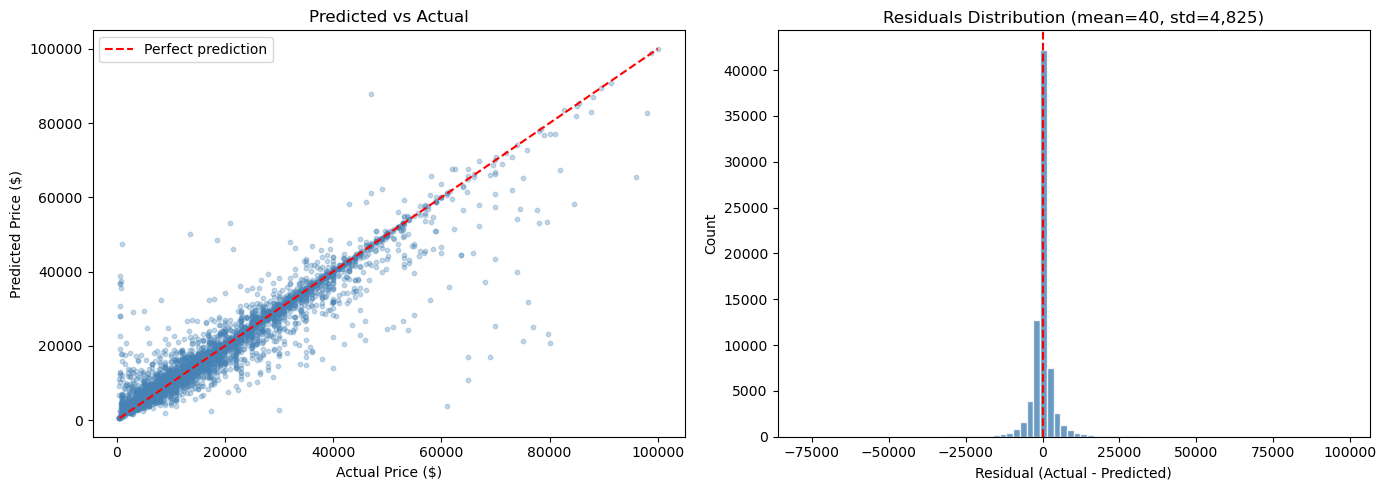

In [7]:
# 3B.6 — Test Set Evaluation
y_pred = rf_best.predict(X_test_processed)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("=== Test Set Metrics ===")
print(f"  MAE:  ${mae:,.2f}")
print(f"  RMSE: ${rmse:,.2f}")
print(f"  R2:   {r2:.4f}")
print(f"  MAPE: {mape:.2%}")

# --- Predicted vs Actual scatter ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

idx = np.random.RandomState(RANDOM_STATE).choice(len(y_test), size=min(5000, len(y_test)), replace=False)

axes[0].scatter(y_test[idx], y_pred[idx], alpha=0.3, s=10, color="steelblue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title("Predicted vs Actual")
axes[0].legend()

# --- Residuals distribution ---
residuals = y_test - y_pred
axes[1].hist(residuals, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color='r', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residuals Distribution (mean={residuals.mean():,.0f}, std={residuals.std():,.0f})")

plt.tight_layout()
plt.show()


## 3B.7 — Feature Importance

Extract and visualize feature importances from the Random Forest.
Feature names are taken directly from the preprocessed DataFrame columns
(preserved by `set_output(transform="pandas")` in the preprocessing pipeline).

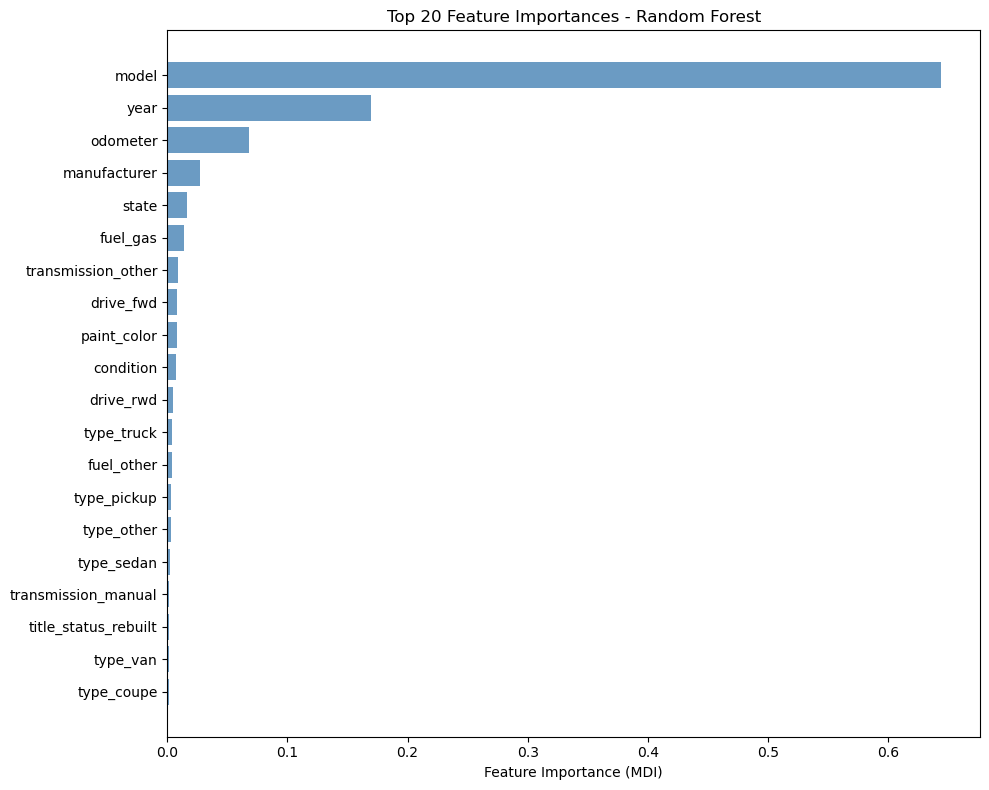


Top 10 features:
  1. model                           0.6442
  2. year                            0.1694
  3. odometer                        0.0683
  4. manufacturer                    0.0269
  5. state                           0.0164
  6. fuel_gas                        0.0142
  7. transmission_other              0.0088
  8. drive_fwd                       0.0082
  9. paint_color                     0.0081
  10. condition                       0.0076


In [8]:
# 3B.7 — Feature Importance
# Feature names come directly from the preprocessed DataFrame columns.

feature_names = X_train_processed.columns.tolist()
importances = rf_best.feature_importances_

# Sort by importance
sorted_idx = np.argsort(importances)
top_n = min(20, len(feature_names))
top_idx = sorted_idx[-top_n:]

# Clean up column names for display (strip transformer prefix)
display_names = [n.split('__', 1)[-1] if '__' in n else n for n in feature_names]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(top_n), importances[top_idx], color='steelblue', alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels([display_names[i] for i in top_idx])
ax.set_xlabel("Feature Importance (MDI)")
ax.set_title(f"Top {top_n} Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

# Print top 10 as a table
print("\nTop 10 features:")
for rank, i in enumerate(sorted_idx[::-1][:10], 1):
    print(f"  {rank}. {display_names[i]:<30s}  {importances[i]:.4f}")


## 3B.8 — Overfitting Analysis

Compare training set performance vs. test set performance to check for overfitting.

In [9]:
# 3B.8 — Overfitting Analysis

# Training set metrics
y_train_pred = rf_best.predict(X_train_processed)
train_mae  = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2   = r2_score(y_train, y_train_pred)
train_mape = mean_absolute_percentage_error(y_train, y_train_pred)

# Comparison table
print('=== Train vs Test Performance ===')
print(f'{"Metric":<8s}  {"Train":>12s}  {"Test":>12s}  {"Gap":>10s}')
print('-' * 46)
print(f'{"MAE":<8s}  ${train_mae:>10,.2f}  ${mae:>10,.2f}  ${mae - train_mae:>8,.2f}')
print(f'{"RMSE":<8s}  ${train_rmse:>10,.2f}  ${rmse:>10,.2f}  ${rmse - train_rmse:>8,.2f}')
print(f'{"R2":<8s}  {train_r2:>11.4f}   {r2:>11.4f}   {r2 - train_r2:>9.4f}')
print(f'{"MAPE":<8s}  {train_mape:>11.2%}   {mape:>11.2%}   {mape - train_mape:>9.2%}')

gap_pct = ((mae - train_mae) / train_mae) * 100
print(f'\nMAE gap: {gap_pct:.1f}% higher on test set')
if gap_pct > 50:
    print('Warning: Significant overfitting detected.')
elif gap_pct > 20:
    print('Moderate overfitting — model generalizes reasonably but has room for improvement.')
else:
    print('Low overfitting — model generalizes well.')


=== Train vs Test Performance ===
Metric           Train          Test         Gap
----------------------------------------------
MAE       $  1,138.64  $  2,154.14  $1,015.50
RMSE      $  2,472.77  $  4,825.40  $2,352.63
R2             0.9705        0.8878     -0.0826
MAPE           20.58%        36.77%      16.19%

MAE gap: 89.2% higher on test set


## 3B.9 Learning curves issue 26

We plot train MAE and CV MAE against training set size. The chart answers if more data would help.

Two reads.

If the curves converge at full data then the model is not data limited. More data would not help much.

If the curves keep diverging then the model would benefit from more data.

We use cv 3 and 4 train sizes to keep wall clock under 30 minutes.


Computing learning curves (4 train sizes x 3 folds = 12 fits)...


  done in 1.1 min

train_size      train_MAE       CV_MAE        gap
--------------------------------------------------
50,856       $     1,396 $     2,712 $   1,316
101,713      $     1,289 $     2,387 $   1,099
152,570      $     1,229 $     2,203 $     974
203,427      $     1,190 $     2,071 $     881


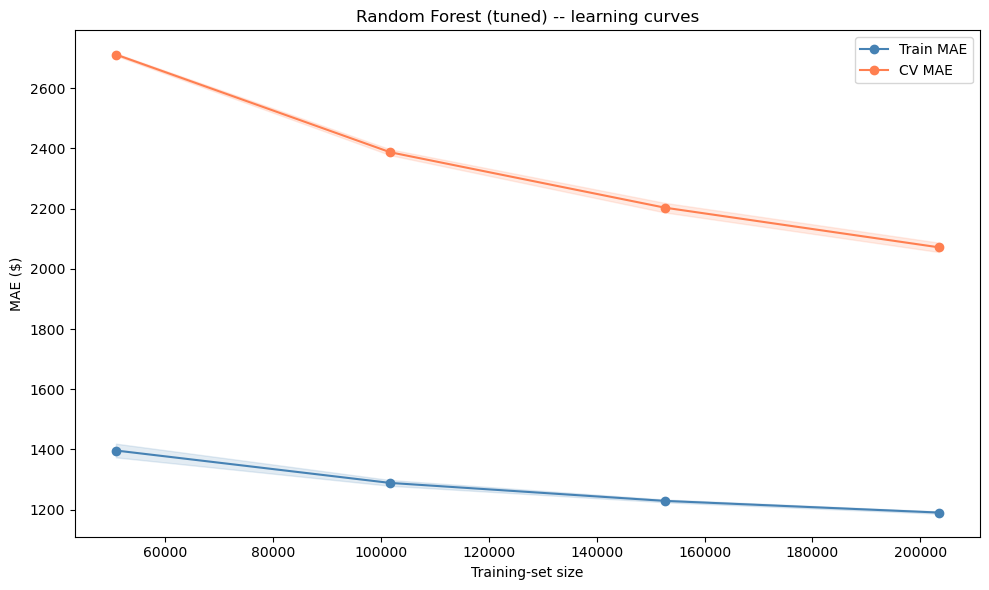

In [10]:
# 3B.9 Learning curves
from sklearn.model_selection import learning_curve

print("Computing learning curves (4 train sizes x 3 folds = 12 fits)...")
t0 = time.time()
train_sizes_abs, train_scores, test_scores = learning_curve(
    rf_best, X_train_processed, y_train,
    train_sizes=np.linspace(0.25, 1.0, 4),
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
print(f"  done in {(time.time() - t0)/60:.1f} min")

train_m = -train_scores.mean(axis=1)
train_s =  train_scores.std(axis=1)
test_m  = -test_scores.mean(axis=1)
test_s  =  test_scores.std(axis=1)

print(f"\n{'train_size':<12} {'train_MAE':>12} {'CV_MAE':>12} {'gap':>10}")
print("-" * 50)
for n, tr, cv in zip(train_sizes_abs, train_m, test_m):
    print(f"{int(n):<12,} ${tr:>10,.0f} ${cv:>10,.0f} ${cv-tr:>8,.0f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes_abs, train_m - train_s, train_m + train_s, alpha=0.15, color="steelblue")
ax.fill_between(train_sizes_abs, test_m - test_s,   test_m + test_s,   alpha=0.15, color="coral")
ax.plot(train_sizes_abs, train_m, "o-", color="steelblue", label="Train MAE")
ax.plot(train_sizes_abs, test_m,  "o-", color="coral",     label="CV MAE")
ax.set_xlabel("Training-set size")
ax.set_ylabel("MAE ($)")
ax.set_title("Random Forest (tuned) -- learning curves")
ax.legend()
plt.tight_layout()
plt.show()


## 3B.10 — Save Model

Compose the fitted preprocessor and the best Random Forest into a single `Pipeline`,
then serialize it to `models/random_forest.pkl`. This way, Notebook 04 can call
`.predict()` on raw (unprocessed) data directly.

In [11]:
# 3B.9 — Save Model
full_pipeline = Pipeline([
    ("preprocess", preprocessor_tree),
    ("model", rf_best),
])

# Sanity check: predict on raw X_test (not pre-transformed)
y_pred_check = full_pipeline.predict(X_test)
check_mae = mean_absolute_error(y_test, y_pred_check)
print(f"Full pipeline MAE on raw test data: ${check_mae:,.2f}")
print(f"Direct model MAE (pre-transformed): ${mae:,.2f}")
assert np.isclose(check_mae, mae, rtol=1e-5), 'Pipeline and direct predictions should match!'
print("Pipeline predictions match direct predictions\n")

joblib.dump(full_pipeline, "../models/random_forest.pkl")
print("Saved: ../models/random_forest.pkl")


Full pipeline MAE on raw test data: $2,154.14
Direct model MAE (pre-transformed): $2,154.14
Pipeline predictions match direct predictions



Saved: ../models/random_forest.pkl
